In [2]:
import openml
import pandas as pd

dataset = openml.datasets.get_dataset(46874)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
df = X.copy()
df['target'] = y
df

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,target
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


In [3]:
df.dtypes

Gender                                     object
Age                                         uint8
City                                       object
Profession                                 object
Academic Pressure                           uint8
Work Pressure                               uint8
CGPA                                      float64
Study Satisfaction                          uint8
Job Satisfaction                            uint8
Sleep Duration                             object
Dietary Habits                             object
Degree                                     object
Have you ever had suicidal thoughts ?      object
Work/Study Hours                            uint8
Financial Stress                          float64
Family History of Mental Illness           object
target                                   category
dtype: object

In [4]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000


In [5]:
df.median(numeric_only=True)

Age                   25.00
Academic Pressure      3.00
Work Pressure          0.00
CGPA                   7.77
Study Satisfaction     3.00
Job Satisfaction       0.00
Work/Study Hours       8.00
Financial Stress       3.00
dtype: float64

## Exploratorní analýza dat — vliv atributů na cílovou proměnnou

Před výběrem atributu zájmu a podmnožiny zájmu analyzujeme korelaci všech atributů s cílovou proměnnou `Depression`.

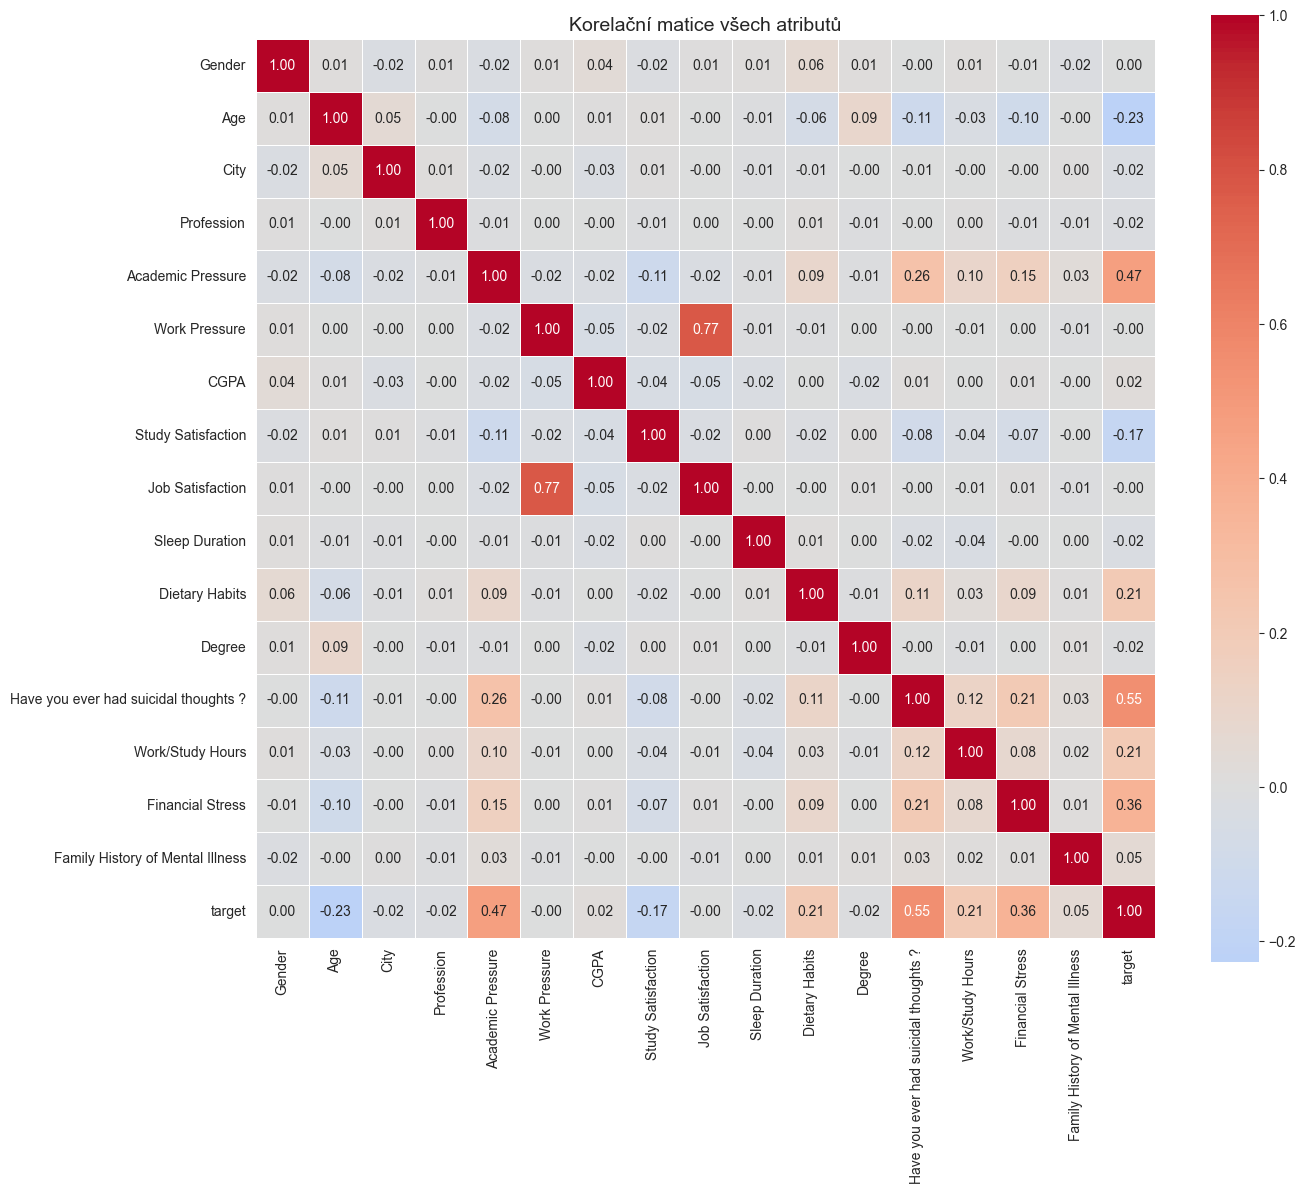

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
df_enc['target'] = df_enc['target'].astype(int)

# Square correlation matrix
corr_matrix = df_enc.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Korelační matice všech atributů', fontsize=14)
plt.tight_layout()
plt.savefig('korelacni_matice.png', dpi=150, bbox_inches='tight')
plt.show()


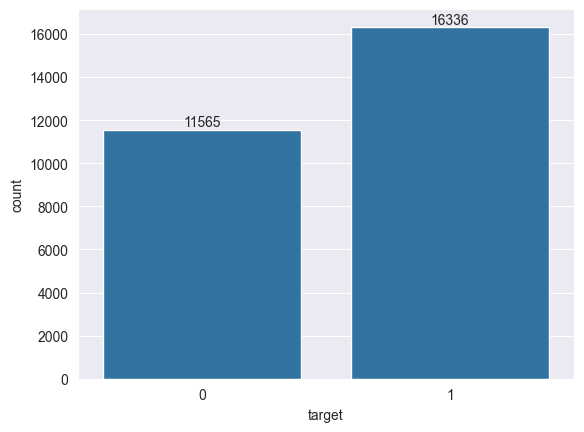

target
1    16336
0    11565
Name: count, dtype: int64


In [7]:
ax = sns.countplot(x='target', data=df)
ax.bar_label(ax.containers[0])
plt.show()
print(df['target'].value_counts())

<Axes: xlabel='Academic Pressure', ylabel='count'>

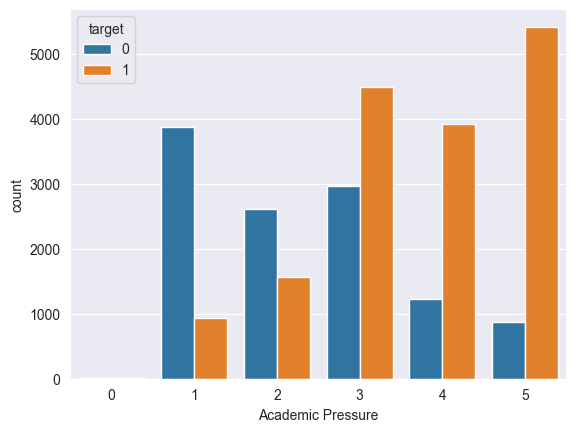

In [8]:
sns.countplot(x='Academic Pressure', hue='target', data=df)

<Axes: xlabel='Financial Stress', ylabel='Density'>

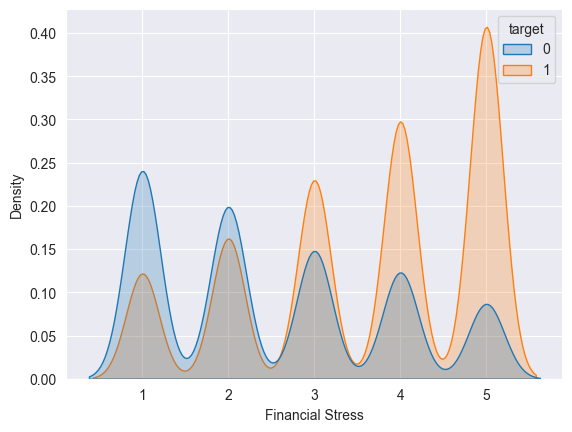

In [9]:
sns.kdeplot(data=df, x='Financial Stress', hue='target', fill=True)